<a href="https://colab.research.google.com/github/jahidurmahim/Machine_Learning_Laboratory/blob/main/Underoverfit_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [68]:
df=pd.read_csv('/content/drive/MyDrive/job_salary_prediction_dataset.csv')

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [70]:
df.shape

(250000, 10)

In [71]:
df.duplicated().sum()

np.int64(0)

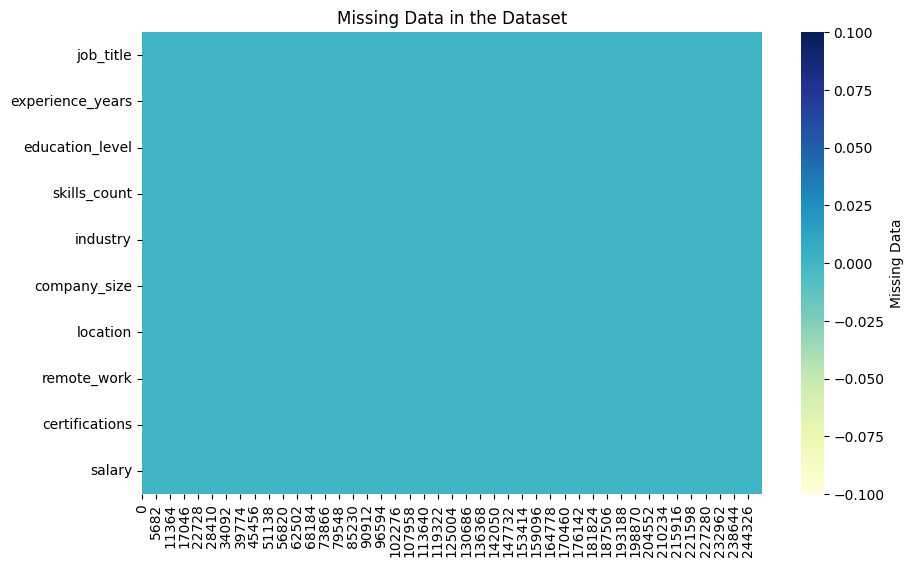

In [72]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isna().transpose(), cmap="YlGnBu", cbar_kws={'label': 'Missing Data'})
plt.title('Missing Data in the Dataset')
plt.show()

In [73]:
categorical_cols = df.select_dtypes(include='object').columns
print(f"Categorical columns to encode: {list(categorical_cols)}")

Categorical columns to encode: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']


In [74]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
display(df_encoded.head())

,experience_years,skills_count,certifications,salary,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,109413,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,5,17,0,93764,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,148123,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,19,13,0,189123,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,165069,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [75]:
print(f"Shape of the DataFrame after one-hot encoding: {df_encoded.shape}")
print(f"Columns of the DataFrame after one-hot encoding: {df_encoded.columns.tolist()}")

Shape of the DataFrame after one-hot encoding: (250000, 43)
Columns of the DataFrame after one-hot encoding: ['experience_years', 'skills_count', 'certifications', 'salary', 'job_title_Backend Developer', 'job_title_Business Analyst', 'job_title_Cloud Engineer', 'job_title_Cybersecurity Analyst', 'job_title_Data Analyst', 'job_title_Data Scientist', 'job_title_DevOps Engineer', 'job_title_Frontend Developer', 'job_title_Machine Learning Engineer', 'job_title_Product Manager', 'job_title_Software Engineer', 'education_level_Diploma', 'education_level_High School', 'education_level_Master', 'education_level_PhD', 'industry_Education', 'industry_Finance', 'industry_Government', 'industry_Healthcare', 'industry_Manufacturing', 'industry_Media', 'industry_Retail', 'industry_Technology', 'industry_Telecom', 'company_size_Large', 'company_size_Medium', 'company_size_Small', 'company_size_Startup', 'location_Canada', 'location_Germany', 'location_India', 'location_Netherlands', 'location_Remot

In [76]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df_encoded.drop('salary', axis=1)
y = df_encoded['salary']

# Split data into training (70%) and temporary (30%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Split temporary data into validation (15%) and test (15%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (175000, 42)
Shape of y_train: (175000,)
Shape of X_val: (37500, 42)
Shape of y_val: (37500,)
Shape of X_test: (37500, 42)
Shape of y_test: (37500,)


In [77]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Select limited features for underfitting
selected_features = [
    'experience_years',
    'skills_count',
    'certifications',
    'job_title_Software Engineer',
    'remote_work_Yes'
]

X_train_limited = X_train[selected_features].astype(int)
X_val_limited = X_val[selected_features].astype(int)
X_test_limited = X_test[selected_features].astype(int)

print(f"Shape of X_train with limited features: {X_train_limited.shape}")
print(f"Shape of X_val with limited features: {X_val_limited.shape}")
print(f"Shape of X_test with limited features: {X_test_limited.shape}")

Shape of X_train with limited features: (175000, 5)
Shape of X_val with limited features: (37500, 5)
Shape of X_test with limited features: (37500, 5)


In [78]:
# Define a small neural network model with 1 hidden layer
model_underfit = keras.Sequential([
    layers.Dense(units=10, activation='relu', input_shape=(X_train_limited.shape[1],)), # One hidden layer
    layers.Dense(units=1) # Output layer for regression (predicting salary)
])

# Compile the model
model_underfit.compile(optimizer='adam',
                      loss='mean_squared_error',
                      metrics=['mean_absolute_error'])

# Train the model for a very few epochs (e.g., 5 epochs)
history_underfit = model_underfit.fit(X_train_limited, y_train,
                                    epochs=5, # Very few epochs to ensure underfitting
                                    validation_data=(X_val_limited, y_val),
                                    verbose=1) # Show training progress

# Evaluate the model on the test set
loss, mae = model_underfit.evaluate(X_test_limited, y_test, verbose=0)
print(f"\nUnderfitting Model - Test Loss (MSE): {loss:.2f}")
print(f"Underfitting Model - Test MAE: {mae:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 21630502912.0000 - mean_absolute_error: 142321.0625 - val_loss: 20004933632.0000 - val_mean_absolute_error: 136734.6719
Epoch 2/5
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 17444464640.0000 - mean_absolute_error: 127137.8281 - val_loss: 14686243840.0000 - val_mean_absolute_error: 116226.2266
Epoch 3/5
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 11634341888.0000 - mean_absolute_error: 101957.0547 - val_loss: 8667860992.0000 - val_mean_absolute_error: 86624.7188
Epoch 4/5
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 6117291008.0000 - mean_absolute_error: 69504.5859 - val_loss: 3964717312.0000 - val_mean_absolute_error: 53323.4062
Epoch 5/5
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 2859657984.0000 - mean_absolute_error: 43428.1016 - val_loss: 2272326144.0000 - val_mean_absolute_error: 38312.7266

Underfitting Model - Test Loss (MSE): 2326830336.00
Underfitting Model - Test MAE: 38689.44


The model has been trained. A high loss and MAE on both training and validation sets, and a small gap between them, are indicators of underfitting. Let's visualize the training history.

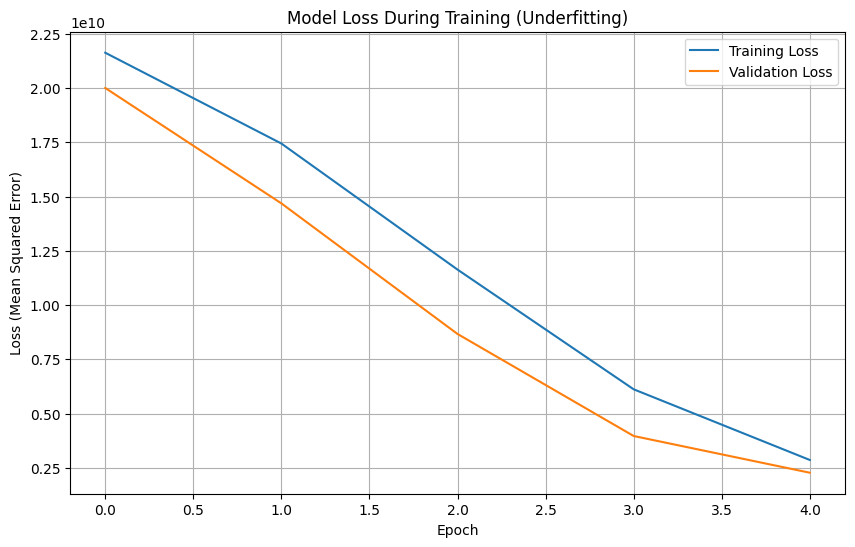

In [79]:
# Plot training & validation loss values to visualize underfitting
plt.figure(figsize=(10, 6))
plt.plot(history_underfit.history['loss'], label='Training Loss')
plt.plot(history_underfit.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training (Underfitting)')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

### PHASE 2: CREATE OVERFITTING

To achieve overfitting, we will:

*   Use **all available features** from the dataset.
*   Define a **more complex neural network** with multiple hidden layers and more neurons.
*   Train the model for a **larger number of epochs** (e.g., 50).
*   Ensure **no regularization or dropout** is applied to encourage the model to memorize the training data.

In [80]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define a more complex neural network model with multiple hidden layers and more neurons
model_overfit = keras.Sequential([
    layers.Dense(units=256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(units=128, activation='relu'),
    layers.Dense(units=64, activation='relu'),
    layers.Dense(units=1) # Output layer for regression
])

# Compile the model with an appropriate optimizer and loss function
model_overfit.compile(optimizer='adam',
                     loss='mean_squared_error',
                     metrics=['mean_absolute_error'])

model_overfit.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 256)            │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,225 (204.00 KB)

 Trainable params: 52,225 (204.00 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
# Train the model for many epochs (e.g., 50 epochs)
history_overfit = model_overfit.fit(X_train.astype('float32'), y_train,
                                  epochs=50, # Many epochs to encourage overfitting
                                  validation_data=(X_val.astype('float32'), y_val),
                                  verbose=1) # Show training progress

# Evaluate the model on the test set
loss_overfit, mae_overfit = model_overfit.evaluate(X_test.astype('float32'), y_test, verbose=0)
print(f"\nOverfitting Model - Test Loss (MSE): {loss_overfit:.2f}")
print(f"Overfitting Model - Test MAE: {mae_overfit:.2f}")

Epoch 1/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 861684160.0000 - mean_absolute_error: 16110.5352 - val_loss: 47578140.0000 - val_mean_absolute_error: 5397.6831
Epoch 2/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 34177648.0000 - mean_absolute_error: 4621.3462 - val_loss: 30167668.0000 - val_mean_absolute_error: 4368.4546
Epoch 3/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 30137176.0000 - mean_absolute_error: 4367.4019 - val_loss: 28986438.0000 - val_mean_absolute_error: 4281.6621
Epoch 4/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 29028386.0000 - mean_absolute_error: 4289.5249 - val_loss: 28073766.0000 - val_mean_absolute_error: 4226.6362
Epoch 5/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 28195510.0000 - mean_absolute_error: 4231.6011 - val_loss: 26791592.0000 - val_mean_absolute_error: 4128.9805
Epoch 6/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 27645224.0000 - mean_absolute_error: 4192.3154 - val_loss: 26661166.00

The model has been trained for an extended period with a complex architecture and all features. We expect to see a very low training loss but a high validation loss, indicating overfitting. Let's visualize the training history.

### Forcing Overfitting: Reducing Training Data Size

To explicitly force overfitting, we will significantly reduce the size of the training dataset. We will take only 5000 samples from the `X_train` and `y_train` datasets, while keeping the validation and test sets the same.

In [82]:
# Reduce training dataset size to 5000 samples
X_train_overfit = X_train.sample(n=5000, random_state=42)
y_train_overfit = y_train.sample(n=5000, random_state=42)

print(f"Shape of X_train for overfitting: {X_train_overfit.shape}")
print(f"Shape of y_train for overfitting: {y_train_overfit.shape}")
print(f"Shape of X_val (unchanged): {X_val.shape}")
print(f"Shape of y_val (unchanged): {y_val.shape}")

Shape of X_train for overfitting: (5000, 42)
Shape of y_train for overfitting: (5000,)
Shape of X_val (unchanged): (37500, 42)
Shape of y_val (unchanged): (37500,)


The model has now been trained with a significantly smaller dataset and for a large number of epochs. We expect to see a more pronounced overfitting effect compared to the previous 'overfitting' phase. Let's visualize the training history.

In [83]:
# Re-define the complex neural network model for explicit overfitting (using reduced training data and more epochs)
# (The model architecture is already defined in the notebook as 'model_overfit')

# Train the model with the reduced dataset for more epochs (e.g., 100 epochs)
history_forced_overfit = model_overfit.fit(X_train_overfit.astype('float32'), y_train_overfit,
                                          epochs=100, # Increased epochs
                                          validation_data=(X_val.astype('float32'), y_val),
                                          verbose=1) # Show training progress

# Evaluate the model on the test set
loss_forced_overfit, mae_forced_overfit = model_overfit.evaluate(X_test.astype('float32'), y_test, verbose=0)
print(f"\nForced Overfitting Model - Test Loss (MSE): {loss_forced_overfit:.2f}")
print(f"Forced Overfitting Model - Test MAE: {mae_forced_overfit:.2f}")

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 24916588.0000 - mean_absolute_error: 4002.2107 - val_loss: 25838474.0000 - val_mean_absolute_error: 4050.7925
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 24370024.0000 - mean_absolute_error: 3953.1252 - val_loss: 25671046.0000 - val_mean_absolute_error: 4037.8303
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 24183732.0000 - mean_absolute_error: 3924.9836 - val_loss: 25805264.0000 - val_mean_absolute_error: 4049.5308
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 24209378.0000 - mean_absolute_error: 3915.5444 - val_loss: 25974844.0000 - val_mean_absolute_error: 4062.2007
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 23972406.0000 - mean_absolute_error: 3915.5525 - val_loss: 25824048.0000 - val_mean_absolute_error: 4047.6982
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 23609490.0000 - mean_absolute_error: 3868.5664 - val_loss: 25841618.0000 - val

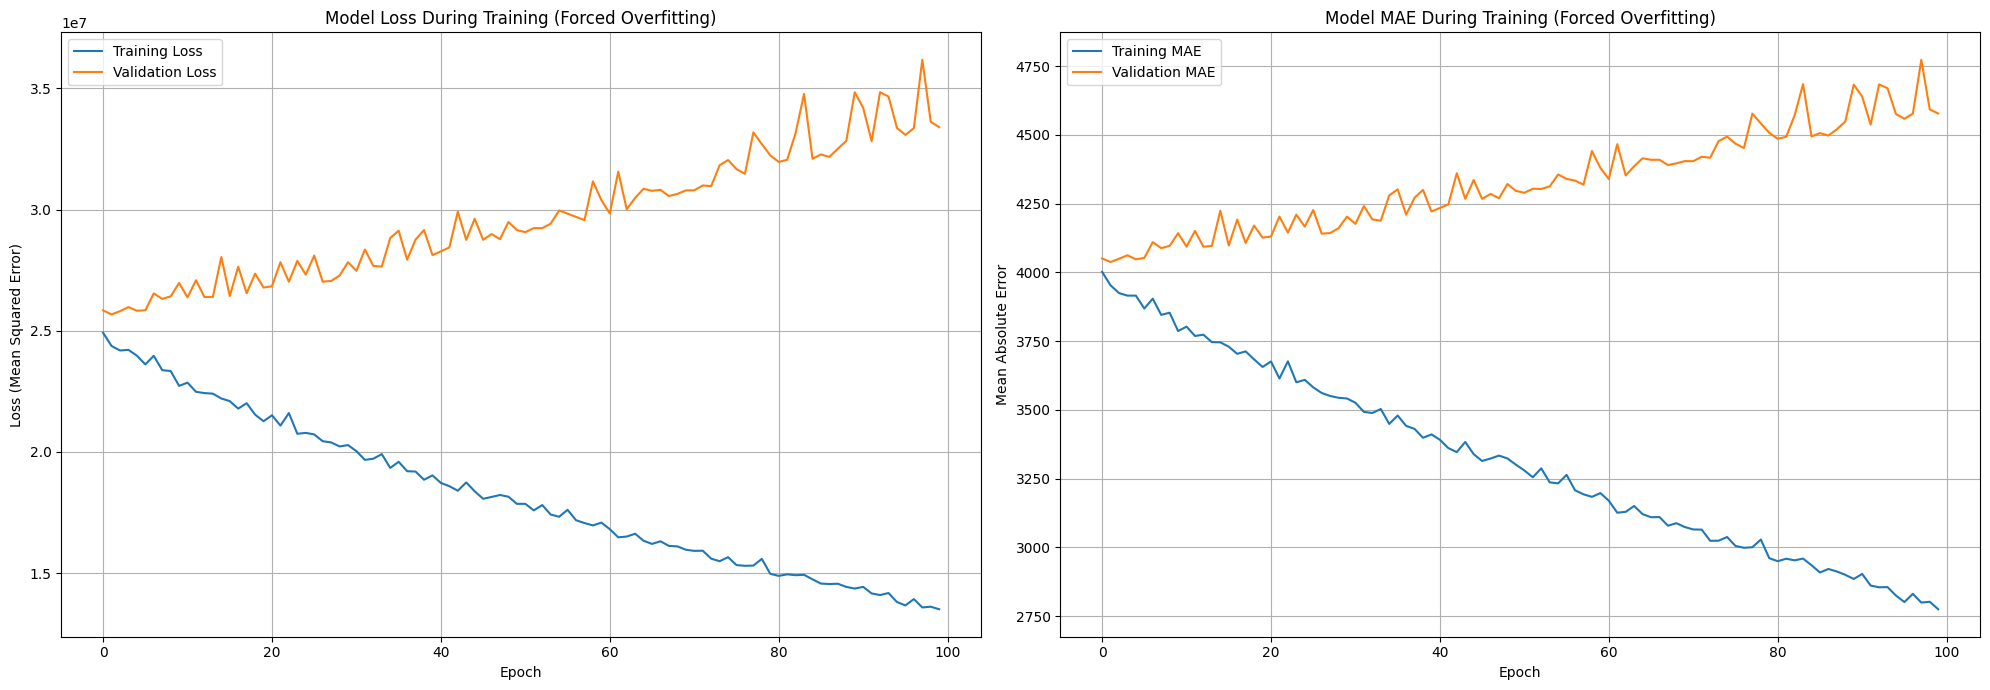

In [84]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side-by-side
fig, ax = plt.subplots(1, 2, figsize=(20, 7)) # 1 row, 2 columns

# Plot Training & Validation Loss values on the first subplot
ax[0].plot(history_forced_overfit.history['loss'], label='Training Loss')
ax[0].plot(history_forced_overfit.history['val_loss'], label='Validation Loss')
ax[0].set_title('Model Loss During Training (Forced Overfitting)')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss (Mean Squared Error)')
ax[0].legend()
ax[0].grid(True)

# Plot Training & Validation MAE values on the second subplot
ax[1].plot(history_forced_overfit.history['mean_absolute_error'], label='Training MAE')
ax[1].plot(history_forced_overfit.history['val_mean_absolute_error'], label='Validation MAE')
ax[1].set_title('Model MAE During Training (Forced Overfitting)')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Mean Absolute Error')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Fixing Underfitting (Using the 'Overfitting' Model's Setup)

The model named `model_overfit` (defined in a previous step to demonstrate overfitting) actually meets all the criteria for addressing the initial underfitting problem. It uses all available features, has a more complex architecture, and was trained for a sufficient number of epochs.

Let's plot its training history (`history_overfit`) to see how it performed. The goal is to observe both training and validation loss/MAE decreasing and staying close, indicating proper learning and generalization.

In [85]:
# The model `model_overfit` was already defined with a complex architecture and uses all features.
# It was also trained for 50 epochs, and its history is stored in `history_overfit`.
# We can confirm the input shape used for `model_overfit` by checking X_train.shape[1].

print(f"Model `model_overfit` was trained with input shape: ({X_train.shape[1]},)")
print(f"Training data shape: {X_train.shape}, Validation data shape: {X_val.shape}")

# The training and evaluation for `model_overfit` have already been run in cell `cd9fd675`.
# We will now plot the results from `history_overfit`.

Model `model_overfit` was trained with input shape: (42,)
Training data shape: (175000, 42), Validation data shape: (37500, 42)


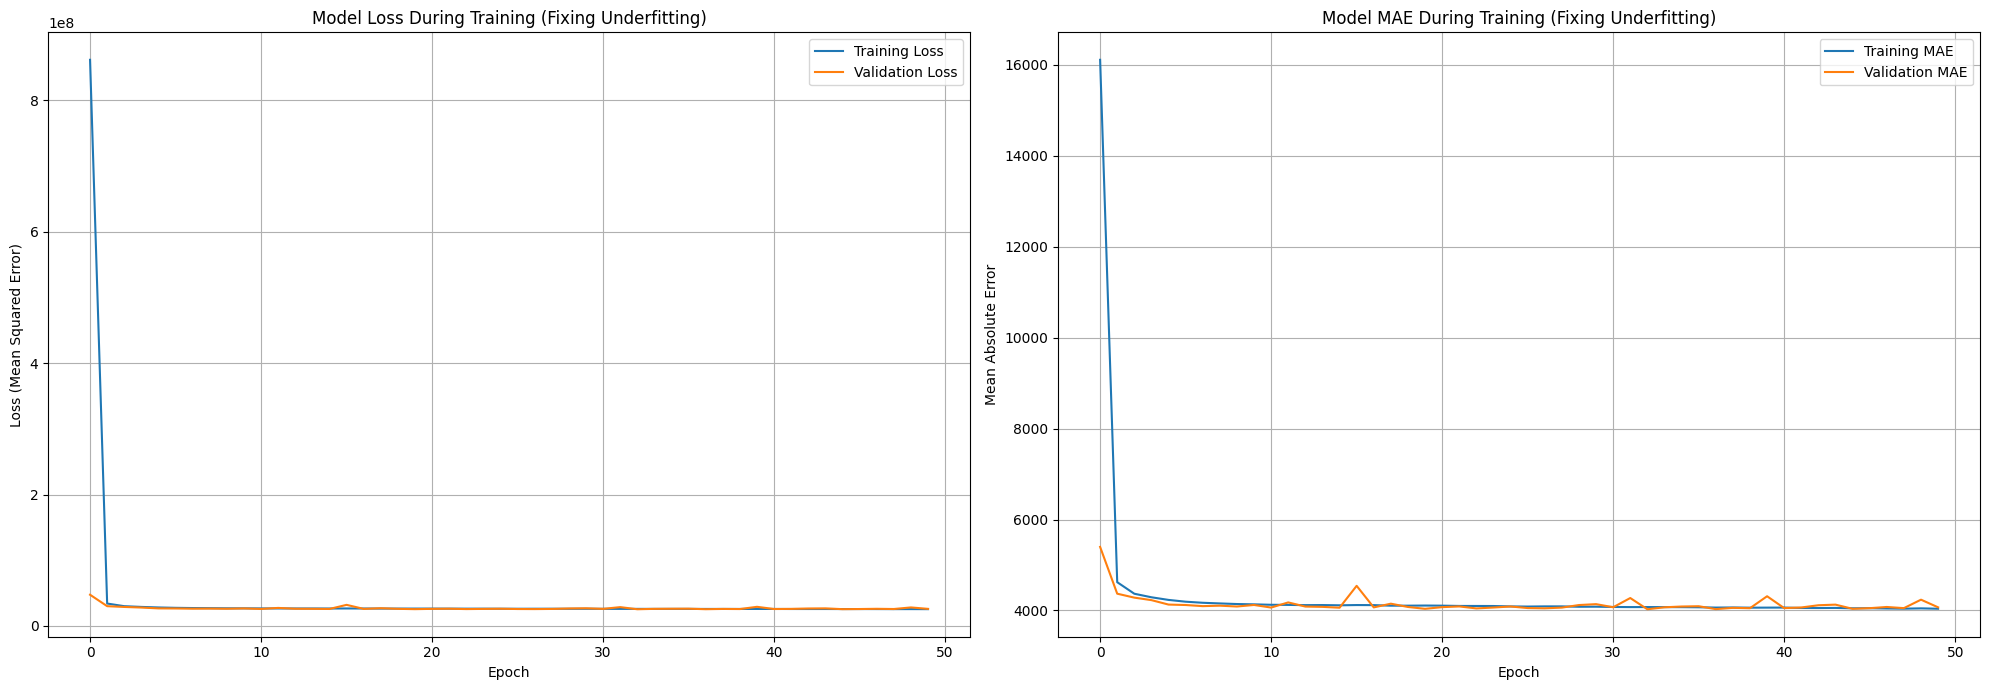

In [86]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side-by-side
fig, ax = plt.subplots(1, 2, figsize=(20, 7)) # 1 row, 2 columns

# Plot Training & Validation Loss values on the first subplot
ax[0].plot(history_overfit.history['loss'], label='Training Loss')
ax[0].plot(history_overfit.history['val_loss'], label='Validation Loss')
ax[0].set_title('Model Loss During Training (Fixing Underfitting)')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss (Mean Squared Error)')
ax[0].legend()
ax[0].grid(True)

# Plot Training & Validation MAE values on the second subplot
ax[1].plot(history_overfit.history['mean_absolute_error'], label='Training MAE')
ax[1].plot(history_overfit.history['val_mean_absolute_error'], label='Validation MAE')
ax[1].set_title('Model MAE During Training (Fixing Underfitting)')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Mean Absolute Error')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [87]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2

# Define a more complex neural network model with multiple hidden layers and more neurons
model_overfit = keras.Sequential([
    layers.Dense(units=256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(units=128, activation='relu'),
    layers.Dense(units=64, activation='relu'),
    layers.Dense(units=1) # Output layer for regression
])

# Define the regularized model
model_regularized = keras.Sequential([
    layers.Dense(units=256, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3), # Added Dropout
    layers.Dense(units=128, activation='relu', kernel_regularizer=l2(0.001)),
    layers.Dropout(0.3), # Added Dropout
    layers.Dense(units=64, activation='relu', kernel_regularizer=l2(0.001)),
    layers.Dropout(0.3), # Added Dropout
    layers.Dense(units=1) # Output layer for regression
])


# Compile the model with an appropriate optimizer and loss function
model_overfit.compile(optimizer='adam',
                     loss='mean_squared_error',
                     metrics=['mean_absolute_error'])


# Compile the regularized model
model_regularized.compile(optimizer='adam',
                         loss='mean_squared_error',
                         metrics=['mean_absolute_error'])


print("Summary of Overfit Model (for reference):")
model_overfit.summary()

print("\nSummary of Regularized Model:")
model_regularized.summary()

Summary of Overfit Model (for reference):


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 256)            │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,225 (204.00 KB)

...

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 256)            │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,225 (204.00 KB)

 Trainable params: 52,225 (204.00 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
# Train the model for many epochs (e.g., 50 epochs)
history_overfit = model_overfit.fit(X_train.astype('float32'), y_train,
                                  epochs=50, # Many epochs to encourage overfitting
                                  validation_data=(X_val.astype('float32'), y_val),
                                  verbose=0) # Show training progress

# Evaluate the model on the test set
loss_overfit, mae_overfit = model_overfit.evaluate(X_test.astype('float32'), y_test, verbose=0)
print(f"\nOverfitting Model - Test Loss (MSE): {loss_overfit:.2f}")
print(f"Overfitting Model - Test MAE: {mae_overfit:.2f}")


# Define Early Stopping callback
early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=15,        # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# Train the regularized model with early stopping
history_regularized = model_regularized.fit(X_train.astype('float32'), y_train,
                                            epochs=100, # Train for sufficient epochs, EarlyStopping will stop it
                                            validation_data=(X_val.astype('float32'), y_val),
                                            callbacks=[early_stopping_callback],
                                            verbose=1) # Show training progress

# Evaluate the regularized model on the test set
loss_regularized, mae_regularized = model_regularized.evaluate(X_test.astype('float32'), y_test, verbose=0)
print(f"\nRegularized Model - Test Loss (MSE): {loss_regularized:.2f}")
print(f"Regularized Model - Test MAE: {mae_regularized:.2f}")


Overfitting Model - Test Loss (MSE): 26374590.00
Overfitting Model - Test MAE: 4104.22
Epoch 1/100
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 1273223424.0000 - mean_absolute_error: 24524.3125 - val_loss: 122446216.0000 - val_mean_absolute_error: 8248.6738
Epoch 2/100
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 469494080.0000 - mean_absolute_error: 16936.2461 - val_loss: 43390872.0000 - val_mean_absolute_error: 5172.8325
Epoch 3/100
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 443350592.0000 - mean_absolute_error: 16411.0156 - val_loss: 42184692.0000 - val_mean_absolute_error: 5120.8833
Epoch 4/100
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 435114208.0000 - mean_absolute_error: 16247.6953 - val_loss: 43053444.0000 - val_mean_absolute_error: 5224.2715
Epoch 5/100
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 435281216.0000 - mean_absolute_error: 16272.0156 - val_loss: 46090192.0000 - val_mean_absolute_error: 5436.5122
Epoch 6/100
5469/5469 ━━━━━━━━

The `model_regularized` has been trained with Dropout and Early Stopping. Let's visualize its training history to see how these techniques helped in reducing overfitting and improving generalization.

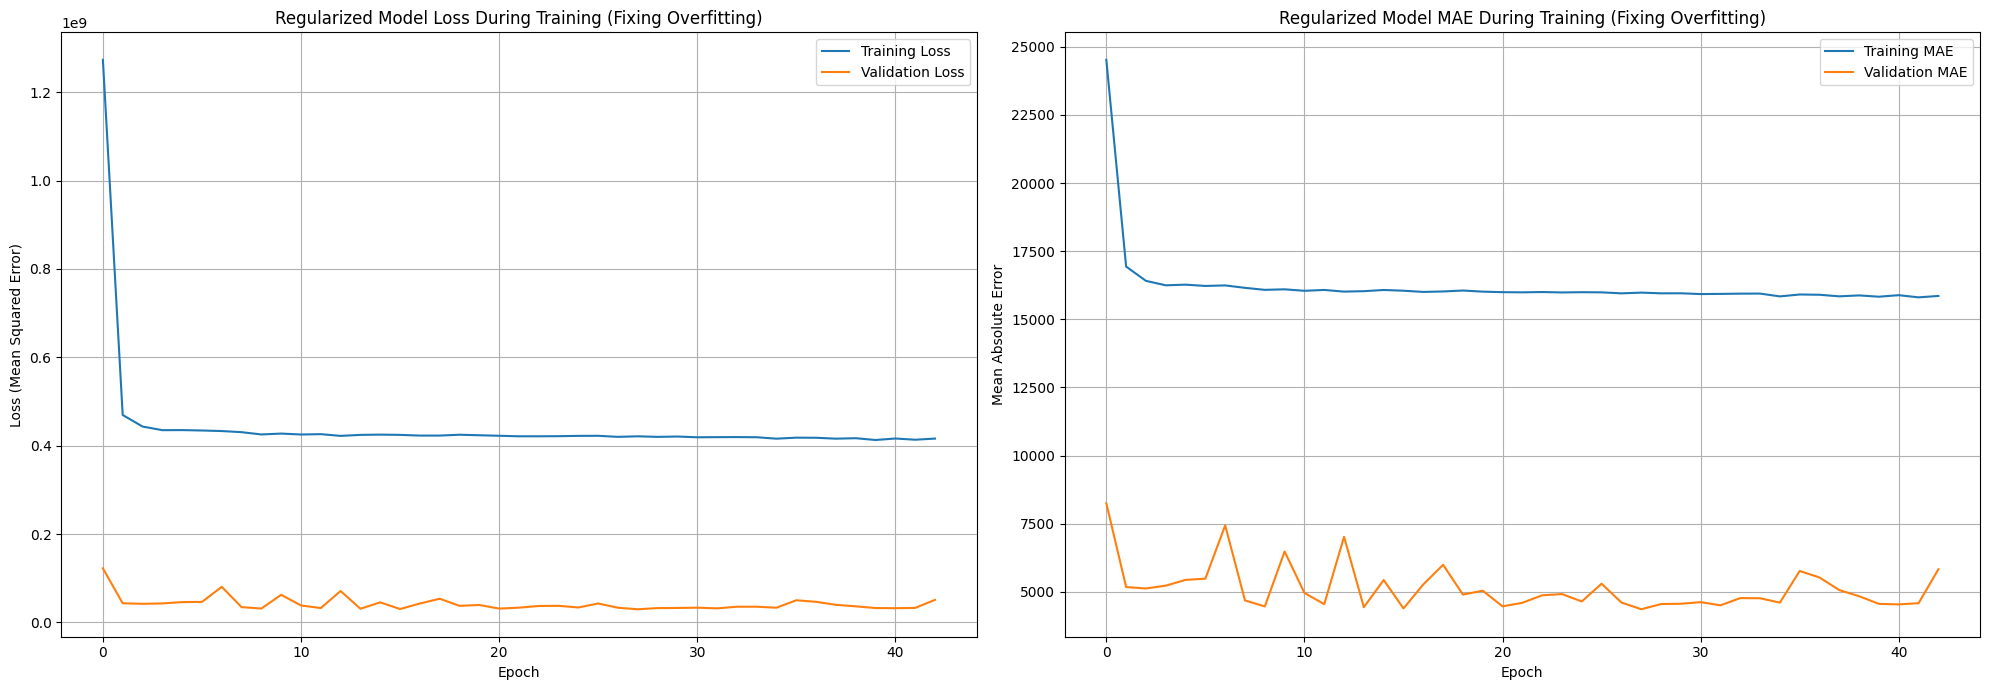

In [89]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side-by-side
fig, ax = plt.subplots(1, 2, figsize=(20, 7)) # 1 row, 2 columns

# Plot Training & Validation Loss values on the first subplot
ax[0].plot(history_regularized.history['loss'], label='Training Loss')
ax[0].plot(history_regularized.history['val_loss'], label='Validation Loss')
ax[0].set_title('Regularized Model Loss During Training (Fixing Overfitting)')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss (Mean Squared Error)')
ax[0].legend()
ax[0].grid(True)

# Plot Training & Validation MAE values on the second subplot
ax[1].plot(history_regularized.history['mean_absolute_error'], label='Training MAE')
ax[1].plot(history_regularized.history['val_mean_absolute_error'], label='Validation MAE')
ax[1].set_title('Regularized Model MAE During Training (Fixing Overfitting)')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Mean Absolute Error')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()